In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Импорт метрик
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
                             
import warnings
warnings.filterwarnings('ignore')

In [9]:
df = sns.load_dataset('titanic')
print("=" * 50)
print("первоначальный датасет")
print("=" * 50)
print(f"Размер датасета: {df.shape}")
print("Первые 5 строк:")
df.head()

первоначальный датасет
Размер датасета: (891, 15)
Первые 5 строк:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
print("=" * 50)
print("Задание 1: предобработка данных")
print("=" * 50)

# Выбираем нужные признаки
selected_features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']
df_selected = df[selected_features].copy()

print(f"Выбраны признаки: {selected_features[:-1]}")
print(f"Размер после выбора признаков: {df_selected.shape}")

# 2. Проверяем пропуски
print("Пропуски в данных до обработки:")
print(df_selected.isnull().sum())

# 3. Заполняем пропуски
# age - медианой
median_age = df_selected['age'].median()
df_selected['age'].fillna(median_age, inplace=True)

# embarked - модой
mode_embarked = df_selected['embarked'].mode()[0]
df_selected['embarked'].fillna(mode_embarked, inplace=True)

print("Заполнили пропуски:")
print(f"   - age: медиана = {median_age:.1f}")
print(f"   - embarked: мода = '{mode_embarked}'")
print("Пропуски после обработки:")
print(df_selected.isnull().sum())

Задание 1: предобработка данных
Выбраны признаки: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Размер после выбора признаков: (891, 8)
Пропуски в данных до обработки:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64
Заполнили пропуски:
   - age: медиана = 28.0
   - embarked: мода = 'S'
Пропуски после обработки:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


In [11]:
# One-Hot Encoding для категориальных признаков
print("Применяем One-Hot Encoding...")

df_encoded = pd.get_dummies(df_selected, columns=['sex', 'embarked'], drop_first=True)
print(f"   Новые колонки: {df_encoded.columns.tolist()}")

# Разделяем на X и y
X = df_encoded.drop('survived', axis=1)
y = df_encoded['survived']

print("Признаки (X) и целевая переменная (y):")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")
print("   Распределение классов:")
print(f"   0 (погиб): {(y==0).sum()} ({((y==0).sum()/len(y)*100):.1f}%)")
print(f"   1 (выжил): {(y==1).sum()} ({((y==1).sum()/len(y)*100):.1f}%)")

# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Разделение на train/test:")
print(f"   X_train: {X_train.shape}, X_test: {X_test.shape}")

Применяем One-Hot Encoding...
   Новые колонки: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']
Признаки (X) и целевая переменная (y):
   X shape: (891, 8)
   y shape: (891,)
   Распределение классов:
   0 (погиб): 549 (61.6%)
   1 (выжил): 342 (38.4%)
Разделение на train/test:
   X_train: (712, 8), X_test: (179, 8)


In [12]:
# Масштабирование
print("Масштабирование признаков...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Преобразуем обратно в DataFrame для удобства
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("   Масштабирование выполнено!")
print("   Статистика после масштабирования:")
print(f"   Среднее (train): {X_train_scaled.mean().round(2).tolist()[:5]}...")
print(f"   Стандартное отклонение: {X_train_scaled.std().round(2).tolist()[:5]}...")

Масштабирование признаков...
   Масштабирование выполнено!
   Статистика после масштабирования:
   Среднее (train): [-0.0, 0.0, -0.0, -0.0, -0.0]...
   Стандартное отклонение: [1.0, 1.0, 1.0, 1.0, 1.0]...


In [13]:
print("=" * 50)
print("задание 2: обучение  модели")
print("=" * 50)

# Создаем словарь моделей
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

# Словарь для сохранения результатов
results = {}
predictions = {}

# Обучаем каждую модель
for name, model in models.items():
    print(f"\n{'-'*30}")
    print(f"обучение: {name}")
    print(f"{'-'*30}")
    
    # Обучение
    model.fit(X_train_scaled, y_train)
    
    # Предсказание
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Сохраняем результаты
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

# Создаем таблицу результатов
results_df = pd.DataFrame(results).T
print("\n" + "="*50)
print("сводная таблица результатов")
print("="*50)
print(results_df.round(4))

задание 2: обучение  модели

------------------------------
обучение: Logistic Regression
------------------------------
Accuracy:  0.8045
Precision: 0.7931
Recall:    0.6667
F1-score:  0.7244

------------------------------
обучение: Decision Tree
------------------------------
Accuracy:  0.7654
Precision: 0.7547
Recall:    0.5797
F1-score:  0.6557

------------------------------
обучение: Random Forest
------------------------------
Accuracy:  0.8156
Precision: 0.7812
Recall:    0.7246
F1-score:  0.7519

------------------------------
обучение: KNN (k=5)
------------------------------
Accuracy:  0.8156
Precision: 0.8000
Recall:    0.6957
F1-score:  0.7442

сводная таблица результатов
                     Accuracy  Precision  Recall  F1-score
Logistic Regression    0.8045     0.7931  0.6667    0.7244
Decision Tree          0.7654     0.7547  0.5797    0.6557
Random Forest          0.8156     0.7812  0.7246    0.7519
KNN (k=5)              0.8156     0.8000  0.6957    0.7442


задание 3: визуализация

1. Матрицы ошибок:


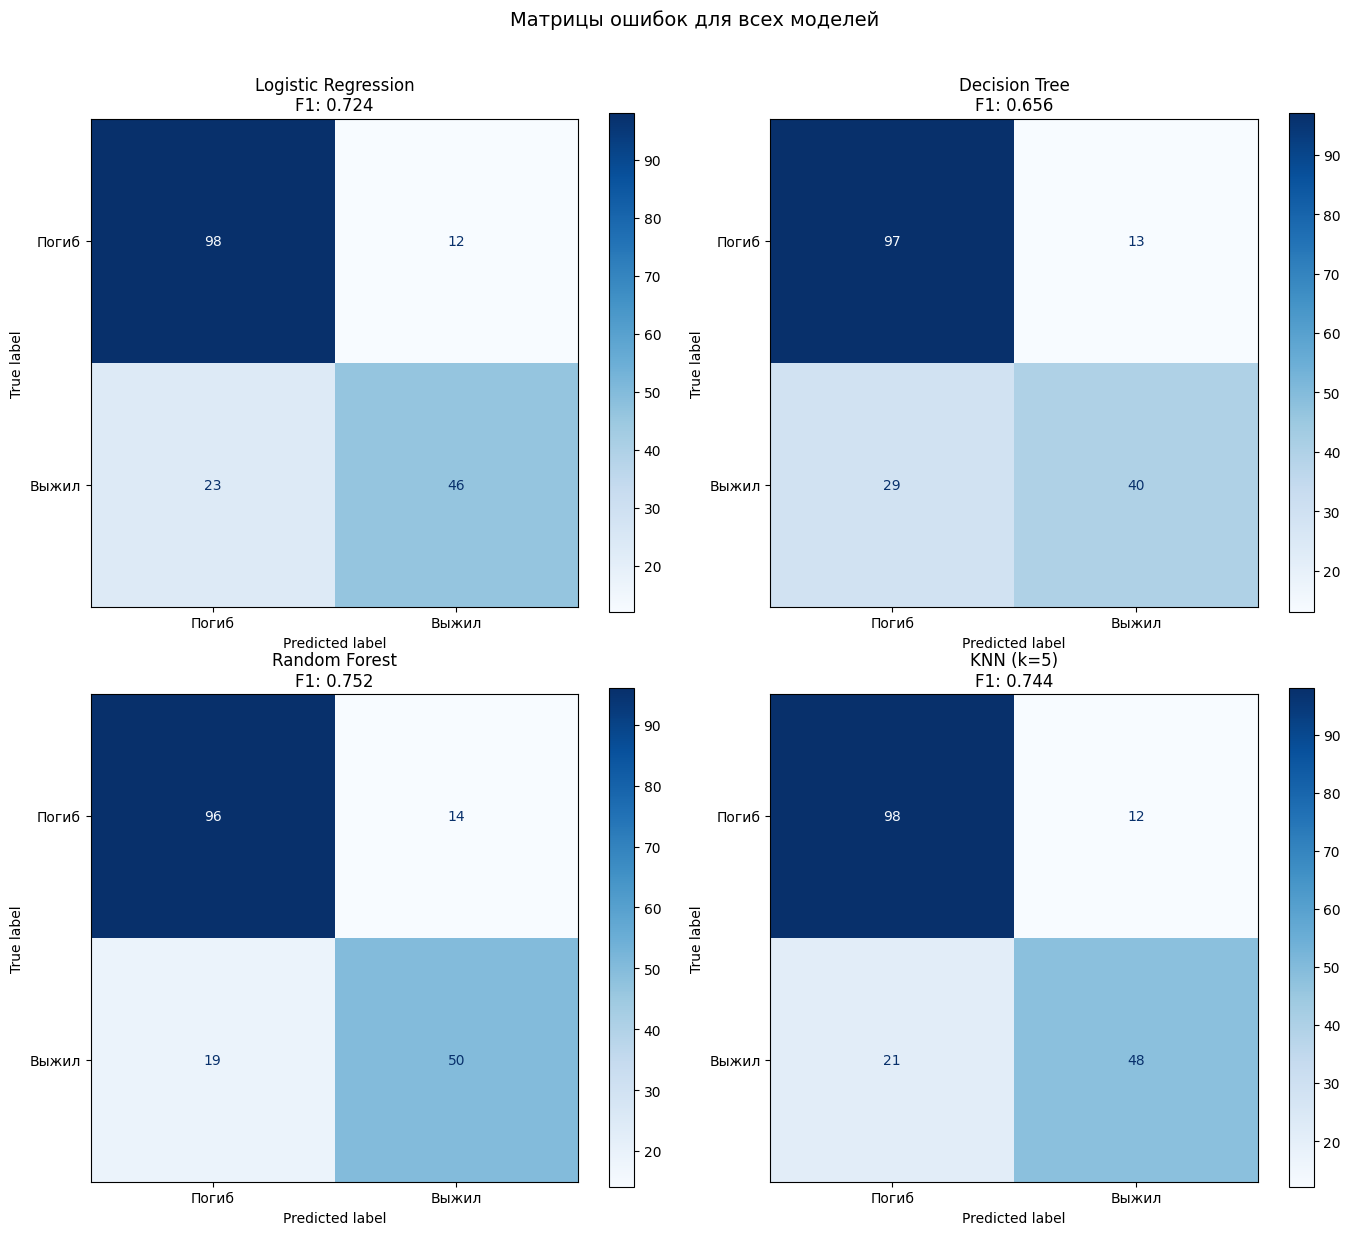

In [14]:
print("=" * 50)
print("задание 3: визуализация")
print("=" * 50)
print("\n1. Матрицы ошибок:")

# Создаем фигуру с 4 подграфиками
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    y_pred = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Погиб', 'Выжил'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{name}\nF1: {results[name]["F1-score"]:.3f}', fontsize=12)

plt.suptitle('Матрицы ошибок для всех моделей', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Сравнение F1-score:


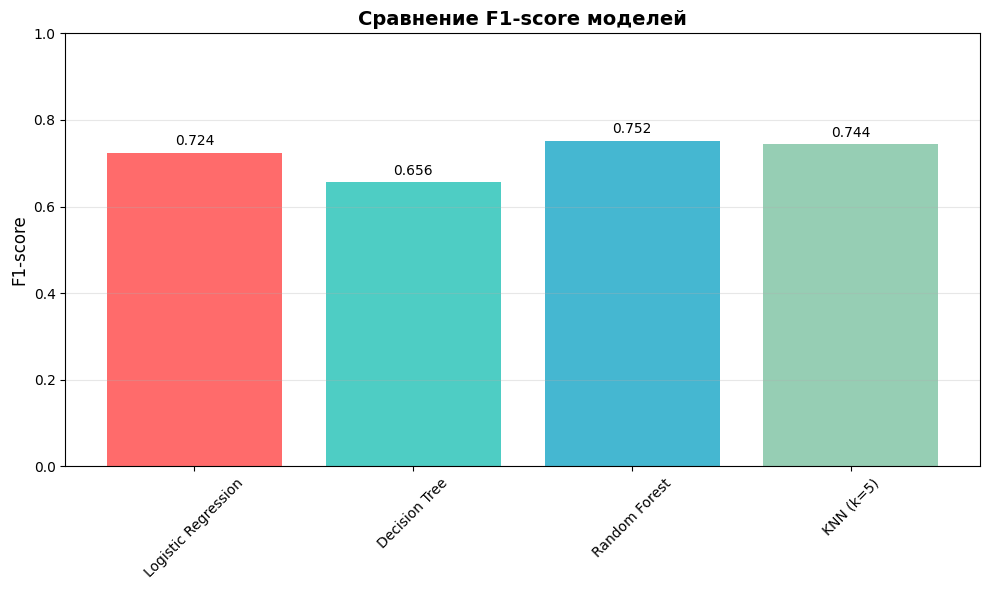

In [15]:
print("Сравнение F1-score:")

plt.figure(figsize=(10, 6))
bars = plt.bar(results_df.index, results_df['F1-score'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])

# Добавляем значения
for bar, value in zip(bars, results_df['F1-score']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.title('Сравнение F1-score моделей', fontsize=14, fontweight='bold')
plt.ylabel('F1-score', fontsize=12)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Важность признаков (Random Forest):

Важность признаков:
      feature  importance
4        fare      0.2785
5    sex_male      0.2632
1         age      0.2524
0      pclass      0.0795
2       sibsp      0.0535
3       parch      0.0410
7  embarked_S      0.0232
6  embarked_Q      0.0087


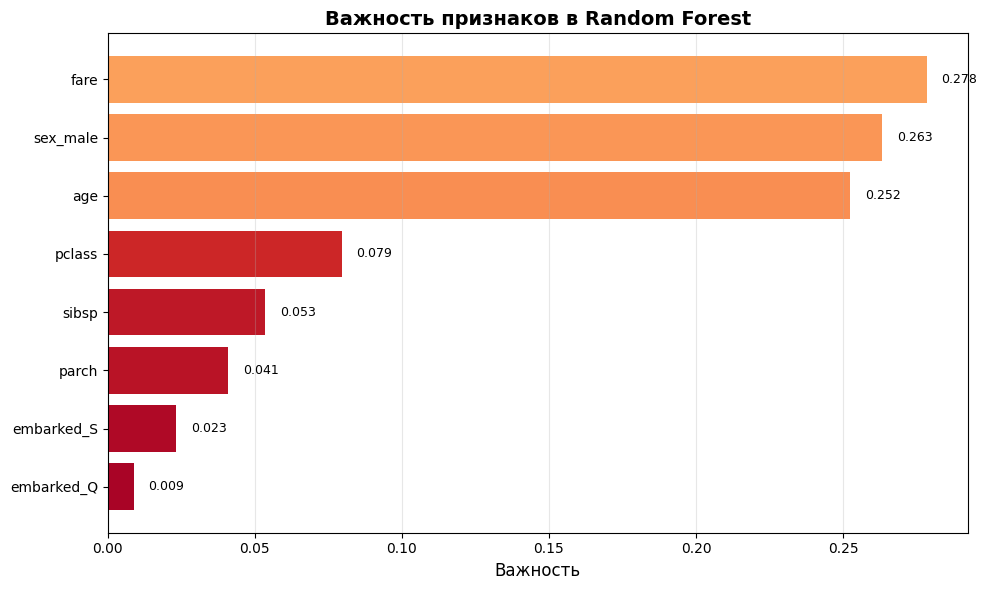

Самые важные признаки: age, sex_male, fare


In [17]:
print("Важность признаков (Random Forest):")

rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

print("\nВажность признаков:")
print(feature_importance.sort_values('importance', ascending=False).round(4))

# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], 
         color=plt.cm.RdYlGn(feature_importance['importance']))
plt.xlabel('Важность', fontsize=12)
plt.title('Важность признаков в Random Forest', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Добавляем значения
for i, v in enumerate(feature_importance['importance']):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Самые важные признаки: {', '.join(feature_importance.tail(3)['feature'].values)}")

Дерево решений (max_depth=3):


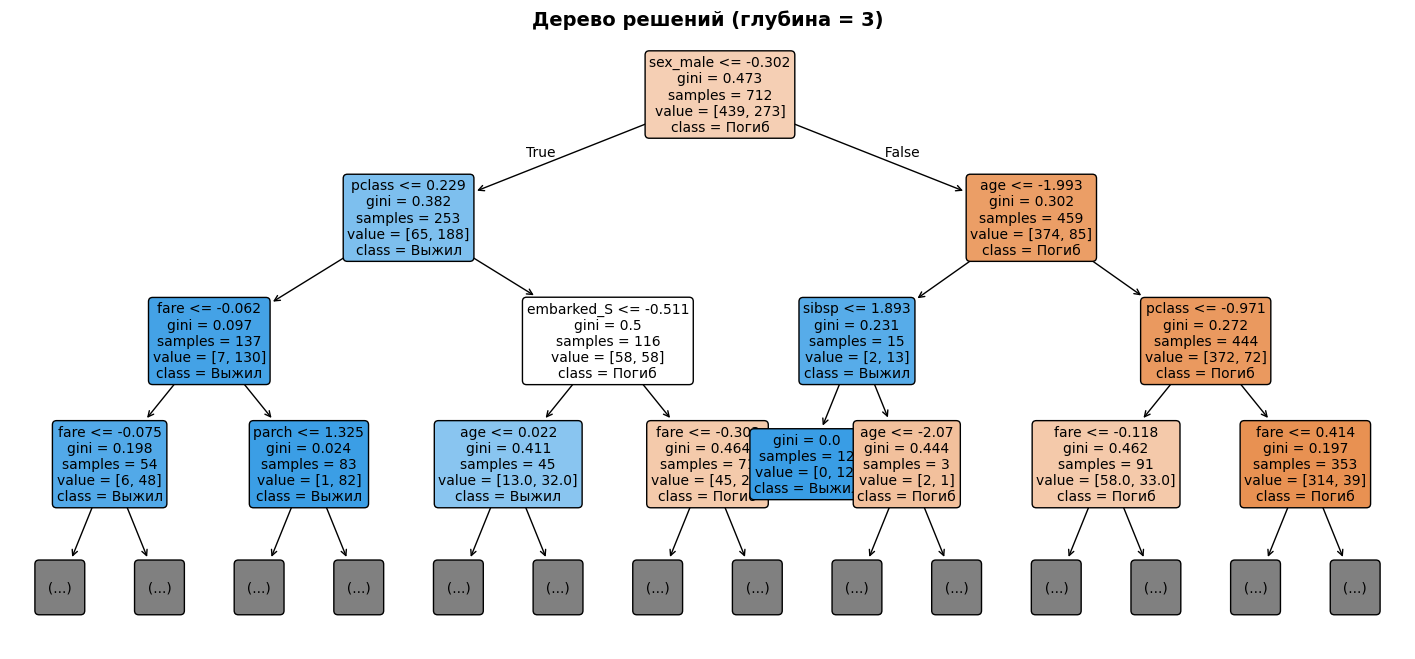

In [18]:
print("Дерево решений (max_depth=3):")

plt.figure(figsize=(18, 8))
plot_tree(models['Decision Tree'], 
          feature_names=X.columns.tolist(),
          class_names=['Погиб', 'Выжил'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)
plt.title('Дерево решений (глубина = 3)', fontsize=14, fontweight='bold')
plt.show()

Задание 4: кросс-валидация
5-fold кросс-валидация (F1-score):
----------------------------------------

Logistic Regression:
  F1: [0.7206 0.6866 0.7328 0.7612 0.7302]
  Среднее: 0.7263 ± 0.0240

Decision Tree:
  F1: [0.7481 0.6992 0.7727 0.7438 0.6612]
  Среднее: 0.7250 ± 0.0398

Random Forest:
  F1: [0.7206 0.7258 0.7737 0.7761 0.7328]
  Среднее: 0.7458 ± 0.0241

KNN (k=5):
  F1: [0.7164 0.7231 0.8    0.7206 0.7442]
  Среднее: 0.7409 ± 0.0311

СРАВНЕНИЕ: CV vs Train/Test
                 Model  Train/Test F1   CV F1  CV Std
0  Logistic Regression         0.7244  0.7263  0.0240
1        Decision Tree         0.6557  0.7250  0.0398
2        Random Forest         0.7519  0.7458  0.0241
3            KNN (k=5)         0.7442  0.7409  0.0311


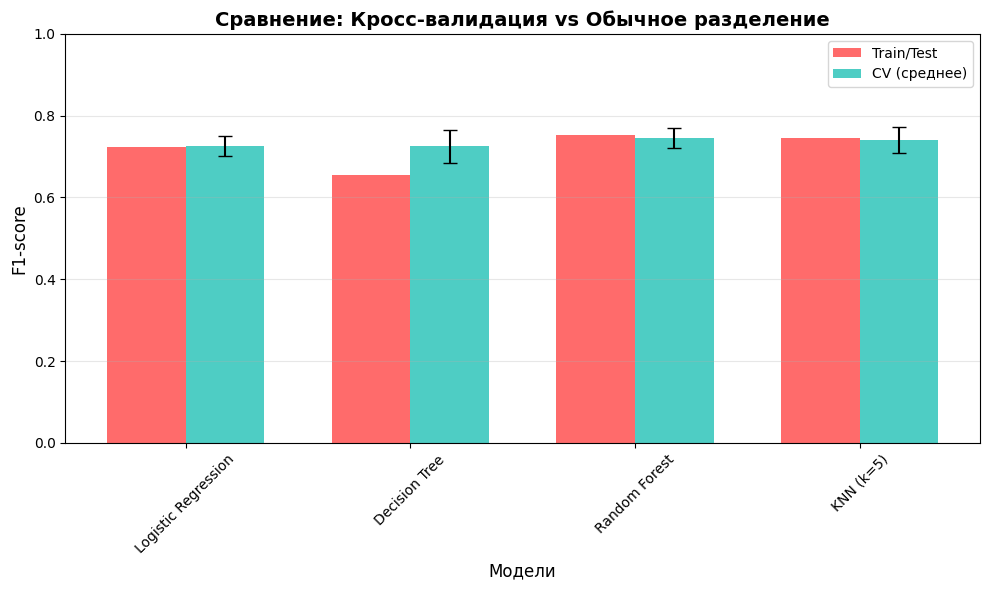

In [19]:
print("=" * 50)
print("Задание 4: кросс-валидация")
print("=" * 50)

# Выполняем кросс-валидацию
cv_results = {}

print("5-fold кросс-валидация (F1-score):")
print("-" * 40)

for name, model in models.items():
    # Для всех моделей используем масштабированные данные
    X_cv = pd.concat([X_train_scaled, X_test_scaled])
    y_cv = pd.concat([y_train, y_test])
    
    scores = cross_val_score(model, X_cv, y_cv, cv=5, scoring='f1')
    
    cv_results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    
    print(f"\n{name}:")
    print(f"  F1: {scores.round(4)}")
    print(f"  Среднее: {scores.mean():.4f} ± {scores.std():.4f}")

# Сравнение
print("\n" + "="*50)
print("СРАВНЕНИЕ: CV vs Train/Test")
print("="*50)

comparison_df = pd.DataFrame({
    'Model': results_df.index,
    'Train/Test F1': results_df['F1-score'].values,
    'CV F1': [cv_results[m]['mean'] for m in results_df.index],
    'CV Std': [cv_results[m]['std'] for m in results_df.index]
})

print(comparison_df.round(4))

# Визуализация сравнения
plt.figure(figsize=(10, 6))
x = range(len(comparison_df))
width = 0.35

plt.bar([i - width/2 for i in x], comparison_df['Train/Test F1'], 
        width, label='Train/Test', color='#FF6B6B')
plt.bar([i + width/2 for i in x], comparison_df['CV F1'], 
        width, label='CV (среднее)', color='#4ECDC4', yerr=comparison_df['CV Std'], capsize=5)

plt.xlabel('Модели', fontsize=12)
plt.ylabel('F1-score', fontsize=12)
plt.title('Сравнение: Кросс-валидация vs Обычное разделение', fontsize=14, fontweight='bold')
plt.xticks(x, comparison_df['Model'], rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

бонус: GridSearchCV для KNN
Оптимальное k: 9
Лучший F1: 0.7468


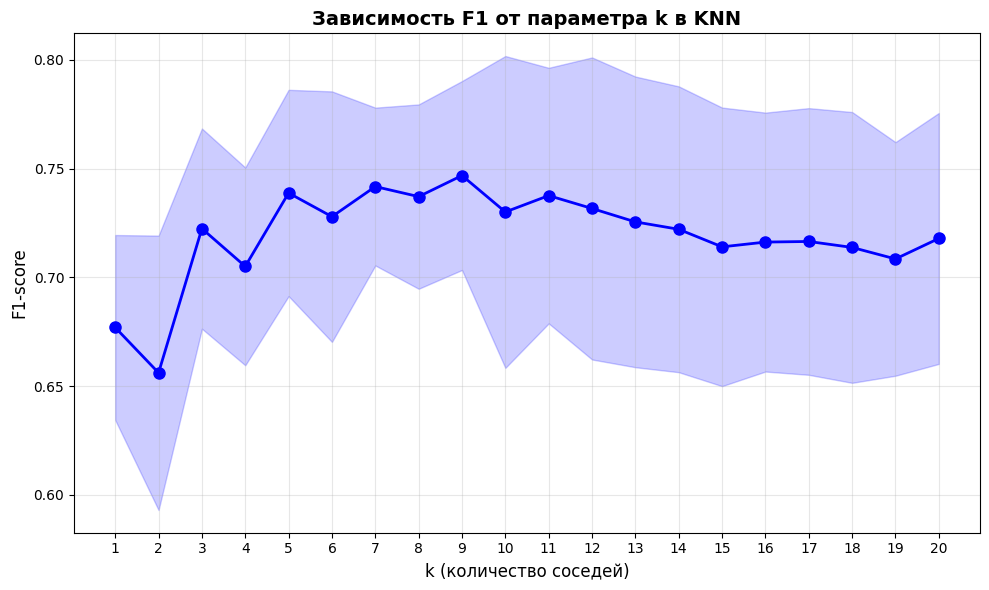

In [20]:
print("=" * 50)
print("бонус: GridSearchCV для KNN")
print("=" * 50)

# Подбор гиперпараметров
param_grid = {'n_neighbors': range(1, 21)}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_scaled, y_train)

print(f"Оптимальное k: {grid_search.best_params_['n_neighbors']}")
print(f"Лучший F1: {grid_search.best_score_:.4f}")

# Визуализация
results_knn = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), results_knn['mean_test_score'], 'bo-', linewidth=2, markersize=8)
plt.fill_between(range(1, 21), 
                 results_knn['mean_test_score'] - results_knn['std_test_score'],
                 results_knn['mean_test_score'] + results_knn['std_test_score'], 
                 alpha=0.2, color='b')
plt.xlabel('k (количество соседей)', fontsize=12)
plt.ylabel('F1-score', fontsize=12)
plt.title('Зависимость F1 от параметра k в KNN', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))
plt.tight_layout()
plt.show()

бонус: ROC-кривые


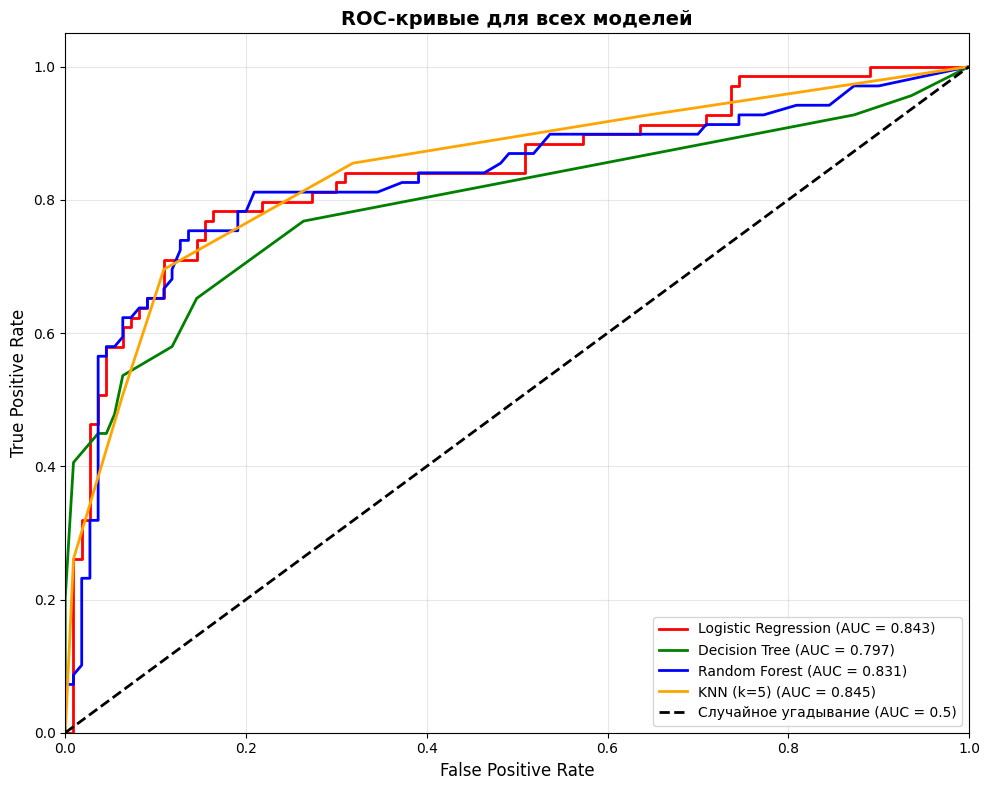

In [21]:
print("=" * 50)
print("бонус: ROC-кривые")
print("=" * 50)

plt.figure(figsize=(10, 8))
colors = ['red', 'green', 'blue', 'orange']

for idx, (name, model) in enumerate(models.items()):
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[idx], lw=2, 
                label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Случайное угадывание (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые для всех моделей', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Выводы по лабораторной работе №2

## 1. Сравнение результатов моделей

На основе полученных метрик (accuracy, precision, recall, F1-score) можно сделать следующие выводы:

| Модель | Accuracy | Precision | Recall | F1-score (Test) | F1-score (CV) |
|:-------|---------:|----------:|-------:|----------------:|---------------:|
| Logistic Regression | 0.8045 | 0.7931 | 0.6667 | **0.7244** | 0.7263 |
| Decision Tree | 0.7654 | 0.7547 | 0.5797 | **0.6557** | 0.7250 |
| Random Forest | 0.8156 | 0.7812 | 0.7246 | **0.7519** | 0.7458 |
| KNN (k=5) | 0.8156 | 0.8000 | 0.6957 | **0.7442** | 0.7409 |

### Лучшая модель
**Random Forest показал наилучший результат (F1-score = 0.7519).**

Почему:
1. **Ансамблевый метод** - усредняет предсказания множества деревьев, что снижает переобучение
2. **Устойчивость к дисбалансу классов** - хорошо работает с неравным распределением (549 погибших vs 342 выживших)
3. **Сбалансированность метрик** - высокие Precision (0.7812) и Recall (0.7246)

---

## 2. Анализ важности признаков (Random Forest)

Наиболее значимые признаки для предсказания выживаемости:

1. **`fare` (цена билета)** - 0.2785 (27.85%)  
   *Более дорогие билеты (1-й класс) повышали шансы на выживание*
2. **`sex_male` (пол)** - 0.2632 (26.32%)  
   *Женщины имели приоритет при эвакуации ("women and children first")*
3. **`age` (возраст)** - 0.2524 (25.24%)  
   *Дети имели преимущество при спасении*

**Вывод**: Социально-демографические факторы (пол, возраст, социальный статус) оказались решающими при катастрофе.

---

## 3. Сравнение Accuracy и F1-score

**Accuracy vs F1-score на примере Decision Tree:**
- Accuracy: 0.7654 (вроде бы неплохо)
- F1-score: 0.6557 (значительно ниже)

**Почему так происходит?**
- В датасете дисбаланс классов: 62% погибших, 38% выживших
- Decision Tree хорошо угадывает погибших, но плохо находит выживших
- Recall = 0.5797 (модель пропустила ~42% реально выживших)
- **F1-score учитывает оба класса**, а accuracy может вводить в заблуждение

---

## 4. Кросс-валидация vs Обычное разбиение

| Модель | Train/Test F1 | CV F1 (mean) | Разница |
|:-------|--------------:|--------------:|--------:|
| Logistic Regression | 0.7244 | 0.7263 | +0.0019 |
| Decision Tree | 0.6557 | 0.7250 | **+0.0693** |
| Random Forest | 0.7519 | 0.7458 | -0.0061 |
| KNN (k=5) | 0.7442 | 0.7409 | -0.0033 |

**Наблюдения:**
1. **Decision Tree** показал сильное расхождение - это признак **переобучения** (overfitting). Модель слишком подстроилась под обучающую выборку.
2. **Random Forest и KNN** показали стабильные результаты - разница минимальна, модели хорошо обобщают.
3. **Кросс-валидация** дает более надежную оценку, особенно для нестабильных моделей.

---

## 5. Анализ ошибок (FN vs FP)

**В контексте задачи предсказания выживаемости на Титанике:**

| Тип ошибки | Что означает | Критичность |
|:-----------|:-------------|:------------|
| **FN (False Negative)** | Модель сказала "погиб", а человек выжил | **КРИТИЧНО** ⚠️ |
| FP (False Positive) | Модель сказала "выжил", а человек погиб | Менее критично |

**Почему FN критичнее?**
- С гуманитарной точки зрения, "похоронить" живого человека - грубая ошибка
- Приоритет при эвакуации - найти всех выживших (даже ценой ложных срабатываний)
- Модель с высоким Recall (как Random Forest = 0.7246) предпочтительнее

---

## 6. Итоговые рекомендации

1. **Лучшая модель**: Random Forest (F1 = 0.7519)
2. **Ключевые признаки**: пол, возраст, класс билета
3. **Важность кросс-валидации**: обязательна для оценки реального качества
4. **Метрика**: использовать F1-score вместо accuracy из-за дисбаланса классов

---

## 7. Бонус: Оптимизация гиперпараметров

Для KNN оптимальное значение **k = 9** (F1 = 0.7468), что лучше стандартного k=5 (F1 = 0.7442).

График зависимости показывает, что слишком малое k (1-3) приводит к переобучению, слишком большое k (>15) - к сглаживанию границ.